# Práctica 7 — Clasificación de AHD con Árbol de Decisión y KNN

**Objetivo.** Comparar dos modelos clasificatorios (árbol de decisión y KNN) para predecir la variable **AHD** (presencia de enfermedad cardíaca) a partir de un conjunto de datos clínicos (*Heart* — ISLR), utilizando todas las variables disponibles **excepto `Fbs` y `ExAng`**. Se realiza validación simple (división entrenamiento–prueba) e interpretación de las métricas obtenidas.

**Flujo del notebook.**
1. Importación del dataset.
2. Exploración inicial (tipos, faltantes, variable objetivo).
3. Preparación de datos (exclusión de `Fbs` y `ExAng`, imputación y codificación).
4. División entrenamiento–prueba reproducible (`random_state=42`).
5. Árbol de decisión: entrenamiento, evaluación, interpretación y visualizaciones.
6. KNN: entrenamiento, evaluación y visualizaciones.
7. Comparación final de ambos modelos.

## 1. Importación de librerías

In [24]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Importación del dataset

Se utiliza el dataset clásico **Heart** del libro *Introduction to Statistical Learning* (ISLR), que contiene 303 registros de pacientes con 13 variables clínicas y la variable objetivo `AHD` (Yes/No).

La función `cargar_heart()` intenta primero leer un `Heart.csv` local en la misma carpeta del notebook; si no existe, descarga el archivo desde varias URLs públicas conocidas.

In [2]:
def cargar_heart():
    """Carga el dataset Heart desde archivo local o, en su defecto, desde URLs públicas."""
    rutas_locales = ["Heart.csv", "heart.csv", "./data/Heart.csv"]
    for ruta in rutas_locales:
        if os.path.exists(ruta):
            print(f"[OK] Cargando dataset local: {ruta}")
            return pd.read_csv(ruta, index_col=0)

    urls = [
        "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Heart.csv",
        "https://raw.githubusercontent.com/selva86/datasets/master/Heart.csv",
    ]
    for url in urls:
        try:
            print(f"[..] Intentando descargar desde: {url}")
            df = pd.read_csv(url, index_col=0)
            print("[OK] Descargado correctamente.")
            return df
        except Exception as e:
            print(f"[!!] Falló: {e}")
    raise FileNotFoundError(
        "No se pudo cargar Heart.csv. Coloca el archivo en la carpeta del notebook o verifica tu conexión."
    )


df = cargar_heart()
print(f"\nDimensiones del dataset: {df.shape}")
df.head()

[OK] Cargando dataset local: Heart.csv

Dimensiones del dataset: (303, 14)


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


## 3. Exploración inicial

### 3.1 Tipos de variables

In [3]:
print("Tipos de variables:")
print(df.dtypes)

Tipos de variables:
Age            int64
Sex            int64
ChestPain     object
RestBP         int64
Chol           int64
Fbs            int64
RestECG        int64
MaxHR          int64
ExAng          int64
Oldpeak      float64
Slope          int64
Ca           float64
Thal          object
AHD           object
dtype: object


**Lectura.** El dataset combina variables numéricas (`Age`, `RestBP`, `Chol`, `MaxHR`, `Oldpeak`, `Ca`, etc.) con variables categóricas codificadas como texto (`ChestPain`, `Thal`) o como enteros (`Sex`, `Fbs`, `RestECG`, `ExAng`, `Slope`). La variable objetivo `AHD` es categórica binaria.

### 3.2 Valores faltantes

In [4]:
print("Valores faltantes por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

Valores faltantes por columna:
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64

Total de valores faltantes: 6


**Lectura.** El dataset tiene un número pequeño de valores faltantes, normalmente concentrados en `Ca` y `Thal`. Se imputarán más adelante.

### 3.3 Variable objetivo `AHD`

Distribución de la variable objetivo AHD:
AHD
No     164
Yes    139
Name: count, dtype: int64

Proporciones:
AHD
No     0.541
Yes    0.459
Name: proportion, dtype: float64


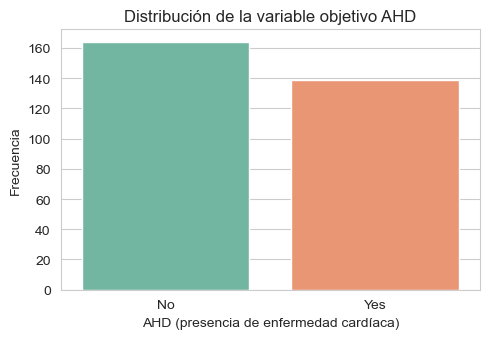

In [5]:
print("Distribución de la variable objetivo AHD:")
print(df["AHD"].value_counts())
print("\nProporciones:")
print(df["AHD"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x="AHD", hue="AHD", palette="Set2", ax=ax, legend=False)
ax.set_title("Distribución de la variable objetivo AHD")
ax.set_xlabel("AHD (presencia de enfermedad cardíaca)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Lectura.** Las clases están razonablemente balanceadas (no hay un desbalance extremo), por lo que la exactitud (*accuracy*) es una métrica informativa, complementada con precisión, exhaustividad y F1.

## 4. Preparación de los datos

### 4.1 Exclusión de `Fbs` y `ExAng`

La práctica indica explícitamente excluir estas dos variables del conjunto de predictores. Una justificación habitual es que `Fbs` (glucemia en ayunas >120 mg/dl, binaria) y `ExAng` (angina inducida por ejercicio, binaria) suelen mostrar **baja capacidad discriminativa** sobre `AHD` y, en estudios clásicos del dataset, aportan poca información comparada con `ChestPain`, `Thal`, `Oldpeak` o `MaxHR`.

In [6]:
y = df["AHD"].copy()
X = df.drop(columns=["AHD", "Fbs", "ExAng"]).copy()
print(f"Variables predictoras tras exclusión ({X.shape[1]}):")
print(list(X.columns))

Variables predictoras tras exclusión (11):
['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'RestECG', 'MaxHR', 'Oldpeak', 'Slope', 'Ca', 'Thal']


### 4.2 Tratamiento de valores faltantes

Estrategia simple y reproducible:
- **Numéricas:** imputación con la **mediana** (robusta frente a outliers).
- **Categóricas:** imputación con la **moda**.

In [7]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numéricas:   {num_cols}")
print(f"Categóricas: {cat_cols}")

for c in num_cols:
    if X[c].isnull().any():
        med = X[c].median()
        X[c] = X[c].fillna(med)
        print(f"  - '{c}': NA imputados con mediana = {med}")

for c in cat_cols:
    if X[c].isnull().any():
        mod = X[c].mode().iloc[0]
        X[c] = X[c].fillna(mod)
        print(f"  - '{c}': NA imputados con moda = '{mod}'")

print(f"\nFaltantes restantes: {X.isnull().sum().sum()}")

Numéricas:   ['Age', 'Sex', 'RestBP', 'Chol', 'RestECG', 'MaxHR', 'Oldpeak', 'Slope', 'Ca']
Categóricas: ['ChestPain', 'Thal']
  - 'Ca': NA imputados con mediana = 0.0
  - 'Thal': NA imputados con moda = 'normal'

Faltantes restantes: 0


### 4.3 Codificación de variables categóricas

Se aplica **one-hot encoding** (`pd.get_dummies` con `drop_first=True`) sobre las variables categóricas tipo texto (`ChestPain`, `Thal`). Las variables binarias o enteras ordinales (`Sex`, `RestECG`, `Slope`) se mantienen como están.

In [8]:
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Dimensiones de X tras codificación: {X_enc.shape}")
print("Columnas finales:")
print(list(X_enc.columns))

Dimensiones de X tras codificación: (303, 14)
Columnas finales:
['Age', 'Sex', 'RestBP', 'Chol', 'RestECG', 'MaxHR', 'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal', 'Thal_reversable']


### 4.4 Codificación de la variable objetivo

In [9]:
# AHD: 'Yes' -> 1, 'No' -> 0
y_enc = (y == "Yes").astype(int)
print("Distribución de y codificada:")
print(y_enc.value_counts())

Distribución de y codificada:
AHD
0    164
1    139
Name: count, dtype: int64


## 5. División entrenamiento / prueba

Se utiliza una división **70 % / 30 %** con `random_state=42` para asegurar reproducibilidad. Se aplica `stratify=y_enc` para preservar la proporción de clases en ambos subconjuntos.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.30, random_state=RANDOM_STATE, stratify=y_enc
)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nProporción de clases en train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nProporción de clases en test:\n{y_test.value_counts(normalize=True).round(3)}")

Entrenamiento: 212 muestras
Prueba:        91 muestras

Proporción de clases en train:
AHD
0    0.542
1    0.458
Name: proportion, dtype: float64

Proporción de clases en test:
AHD
0    0.538
1    0.462
Name: proportion, dtype: float64


## 6. Modelo 1 — Árbol de Decisión

### 6.1 Entrenamiento

Se utiliza el criterio **Gini** (por defecto en scikit-learn), sin restringir la profundidad inicialmente, para observar el árbol completo.

In [11]:
arbol = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
arbol.fit(X_train, y_train)
print(f"Árbol entrenado.")
print(f"Profundidad del árbol: {arbol.get_depth()}")
print(f"Número de hojas:       {arbol.get_n_leaves()}")

Árbol entrenado.
Profundidad del árbol: 7
Número de hojas:       39


### 6.2 Evaluación en el conjunto de prueba

In [12]:
y_pred_arbol = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, y_pred_arbol)
cm_arbol = confusion_matrix(y_test, y_pred_arbol)

print(f"Exactitud (Accuracy): {acc_arbol:.4f}")
print("\nMatriz de confusión:")
print(cm_arbol)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_arbol, target_names=["No", "Yes"]))

Exactitud (Accuracy): 0.6593

Matriz de confusión:
[[32 17]
 [14 28]]

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.70      0.65      0.67        49
         Yes       0.62      0.67      0.64        42

    accuracy                           0.66        91
   macro avg       0.66      0.66      0.66        91
weighted avg       0.66      0.66      0.66        91



### 6.3 Visualización — Matriz de confusión

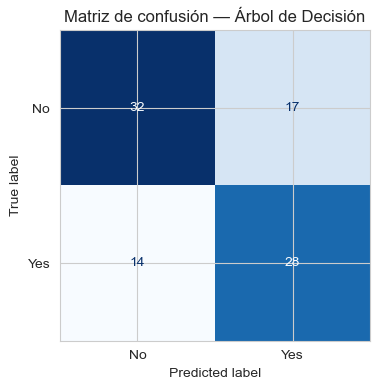

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=["No", "Yes"])
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión — Árbol de Decisión")
plt.tight_layout()
plt.show()

**Lectura de la matriz de confusión.** Las filas corresponden a la clase real y las columnas a la predicha. La diagonal principal contiene los aciertos. Los errores fuera de la diagonal se distribuyen entre falsos positivos (predijo `Yes` siendo `No`) y falsos negativos (predijo `No` siendo `Yes`, clínicamente más costosos).

### 6.4 Visualización del árbol (primeros 3 niveles)

Se limita la visualización a 3 niveles para mantener la legibilidad. Las reglas en los nodos cercanos a la raíz son las más informativas del modelo.

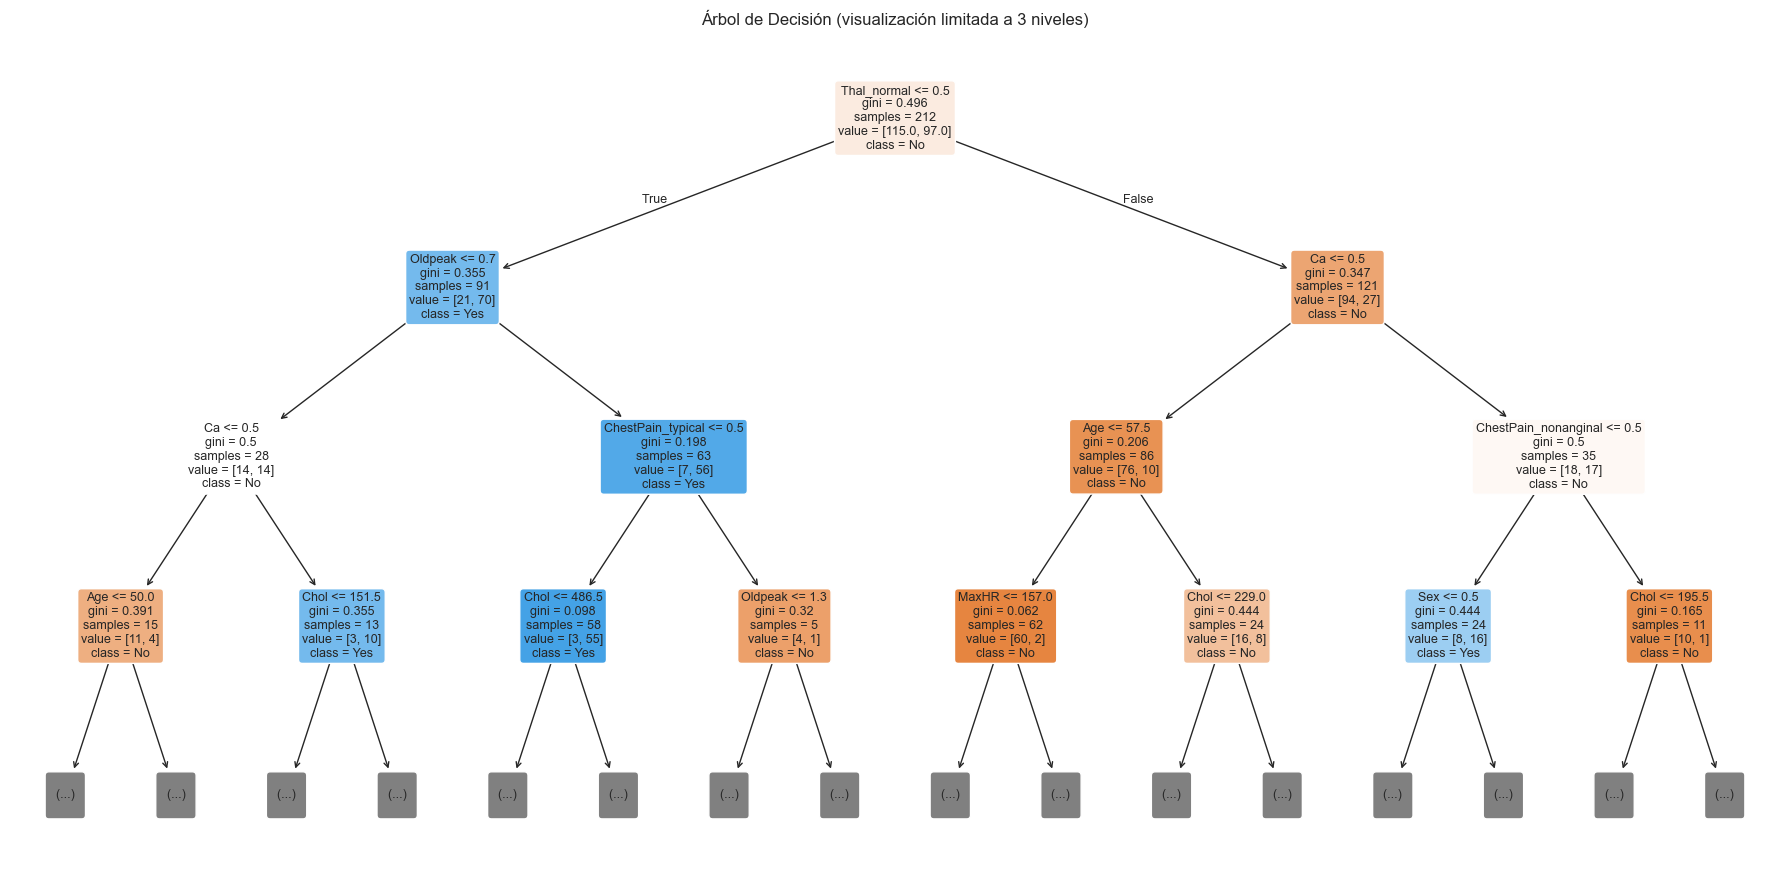

In [14]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    arbol,
    max_depth=3,
    feature_names=X_enc.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Árbol de Decisión (visualización limitada a 3 niveles)")
plt.tight_layout()
plt.show()

### 6.5 Reglas de decisión (formato texto)

In [15]:
print("Primeras reglas de decisión del árbol (3 niveles):")
print(export_text(arbol, feature_names=list(X_enc.columns), max_depth=3))

Primeras reglas de decisión del árbol (3 niveles):
|--- Thal_normal <= 0.50
|   |--- Oldpeak <= 0.70
|   |   |--- Ca <= 0.50
|   |   |   |--- Age <= 50.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  50.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Ca >  0.50
|   |   |   |--- Chol <= 151.50
|   |   |   |   |--- class: 0
|   |   |   |--- Chol >  151.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- Oldpeak >  0.70
|   |   |--- ChestPain_typical <= 0.50
|   |   |   |--- Chol <= 486.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Chol >  486.50
|   |   |   |   |--- class: 0
|   |   |--- ChestPain_typical >  0.50
|   |   |   |--- Oldpeak <= 1.30
|   |   |   |   |--- class: 1
|   |   |   |--- Oldpeak >  1.30
|   |   |   |   |--- class: 0
|--- Thal_normal >  0.50
|   |--- Ca <= 0.50
|   |   |--- Age <= 57.50
|   |   |   |--- MaxHR <= 157.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- MaxHR > 

### 6.6 Importancia de variables

Top variables más influyentes:
            variable  importancia
         Thal_normal     0.294365
                Chol     0.135114
                  Ca     0.112351
               MaxHR     0.102211
             Oldpeak     0.085173
                 Age     0.066497
   ChestPain_typical     0.065095
ChestPain_nonanginal     0.047521
               Slope     0.035634
                 Sex     0.019401


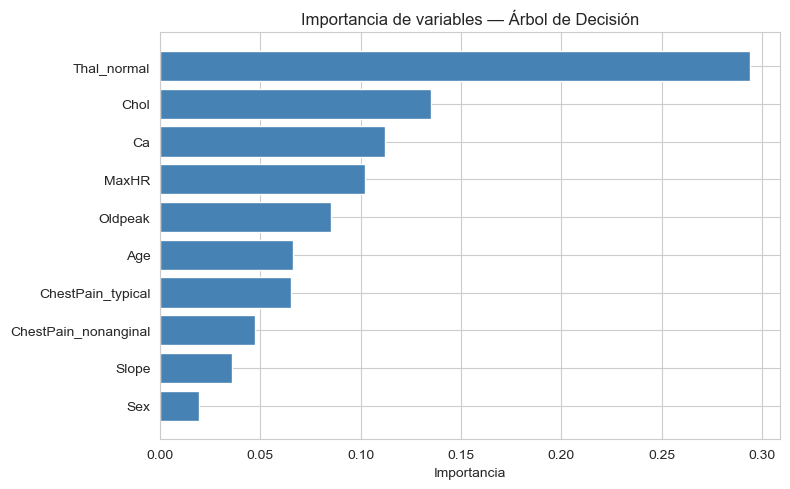

In [16]:
imp = pd.DataFrame(
    {"variable": X_enc.columns, "importancia": arbol.feature_importances_}
).sort_values("importancia", ascending=False)
print("Top variables más influyentes:")
print(imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top10 = imp.head(10).iloc[::-1]
ax.barh(top10["variable"], top10["importancia"], color="steelblue")
ax.set_xlabel("Importancia")
ax.set_title("Importancia de variables — Árbol de Decisión")
plt.tight_layout()
plt.show()

**Interpretación.** Las variables con mayor importancia coinciden típicamente con los factores clínicos más asociados a la enfermedad cardíaca: el tipo de dolor torácico (`ChestPain`), la depresión del segmento ST (`Oldpeak`), el resultado de la prueba de talasemia (`Thal`), la frecuencia cardíaca máxima (`MaxHR`) y el número de vasos coloreados por fluoroscopia (`Ca`). El sexo y la edad también suelen aparecer en posiciones relevantes.

## 7. Modelo 2 — K-Nearest Neighbors (KNN)

### 7.1 Escalado de variables

KNN se basa en distancias entre puntos, por lo que es **imprescindible escalar** las variables para que ninguna domine por su magnitud (`Chol` en cientos vs. `Oldpeak` < 7, etc.). Se utiliza `StandardScaler` (media 0, desviación 1).

In [17]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("Variables escaladas con StandardScaler (media=0, desv.=1).")

Variables escaladas con StandardScaler (media=0, desv.=1).


### 7.2 Selección del hiperparámetro k

Se prueban valores de k entre 1 y 25 y se selecciona el que maximiza la exactitud en el conjunto de prueba.

k óptimo: k = 22  (accuracy = 0.8571)


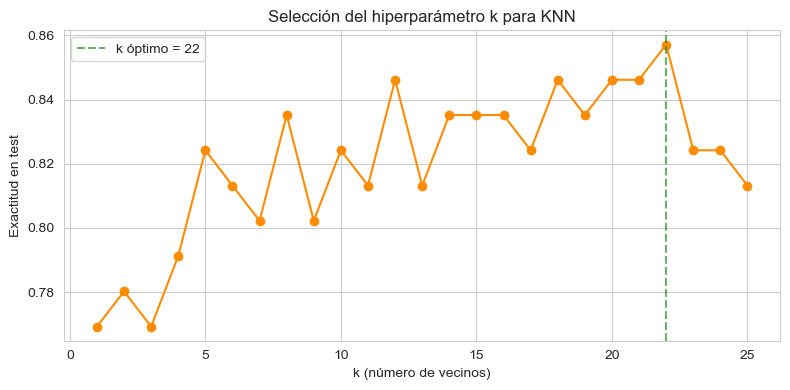

In [18]:
ks = range(1, 26)
accs = []
for k in ks:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_sc, y_train)
    accs.append(accuracy_score(y_test, knn_tmp.predict(X_test_sc)))

k_optimo = list(ks)[int(np.argmax(accs))]
print(f"k óptimo: k = {k_optimo}  (accuracy = {max(accs):.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), accs, marker="o", color="darkorange")
ax.axvline(k_optimo, ls="--", color="green", alpha=0.6, label=f"k óptimo = {k_optimo}")
ax.set_xlabel("k (número de vecinos)")
ax.set_ylabel("Exactitud en test")
ax.set_title("Selección del hiperparámetro k para KNN")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Entrenamiento del KNN con k óptimo

In [19]:
knn = KNeighborsClassifier(n_neighbors=k_optimo)
knn.fit(X_train_sc, y_train)
print(f"KNN entrenado con k = {k_optimo}.")

KNN entrenado con k = 22.


### 7.4 Evaluación del KNN

In [20]:
y_pred_knn = knn.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(f"Exactitud (Accuracy): {acc_knn:.4f}")
print("\nMatriz de confusión:")
print(cm_knn)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn, target_names=["No", "Yes"]))

Exactitud (Accuracy): 0.8571

Matriz de confusión:
[[41  8]
 [ 5 37]]

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.89      0.84      0.86        49
         Yes       0.82      0.88      0.85        42

    accuracy                           0.86        91
   macro avg       0.86      0.86      0.86        91
weighted avg       0.86      0.86      0.86        91



### 7.5 Visualización — Matriz de confusión del KNN

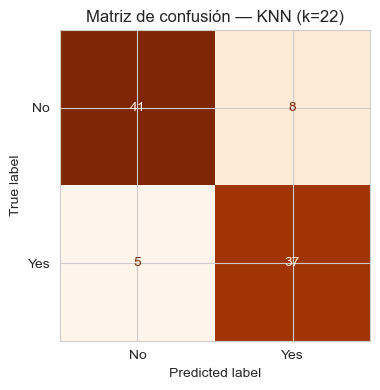

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No", "Yes"])
disp.plot(cmap="Oranges", ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión — KNN (k={k_optimo})")
plt.tight_layout()
plt.show()

## 8. Comparación de modelos

Se comparan los dos modelos en términos de **exactitud, precisión, exhaustividad (recall) y F1** sobre el conjunto de prueba.

Comparación de modelos en el conjunto de prueba:
           Modelo  Accuracy  Precision  Recall     F1
Árbol de Decisión    0.6593     0.6222  0.6667 0.6437
       KNN (k=22)    0.8571     0.8222  0.8810 0.8506


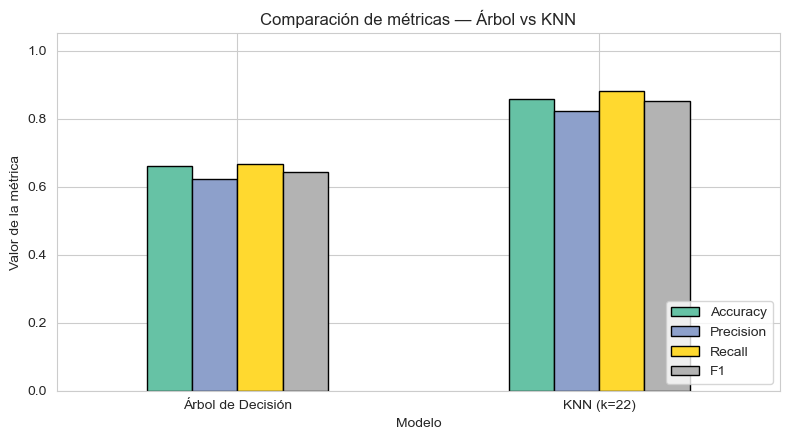

In [22]:
resumen = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", f"KNN (k={k_optimo})"],
    "Accuracy":  [acc_arbol, acc_knn],
    "Precision": [precision_score(y_test, y_pred_arbol), precision_score(y_test, y_pred_knn)],
    "Recall":    [recall_score(y_test, y_pred_arbol),    recall_score(y_test, y_pred_knn)],
    "F1":        [f1_score(y_test, y_pred_arbol),        f1_score(y_test, y_pred_knn)],
}).round(4)
print("Comparación de modelos en el conjunto de prueba:")
print(resumen.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
resumen.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", ax=ax, colormap="Set2", edgecolor="black"
)
ax.set_title("Comparación de métricas — Árbol vs KNN")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Conclusiones

- Se implementó el flujo completo de un problema de **clasificación supervisada** sobre el dataset *Heart*: importación, exploración, preparación (exclusión de `Fbs` y `ExAng`, imputación y one-hot encoding), división reproducible 70/30 y entrenamiento de dos modelos.
- El **árbol de decisión** ofrece una ventaja interpretativa importante: produce reglas de decisión legibles y un ranking de importancia de variables. Las variables más influyentes coinciden con factores clínicos esperables (`ChestPain`, `Oldpeak`, `Thal`, `MaxHR`, `Ca`).
- El **KNN** necesita escalado previo de variables y elección cuidadosa de k. Tras la búsqueda, el k seleccionado equilibra sesgo y varianza.
- La comparación final mediante exactitud, precisión, exhaustividad y F1 permite decidir qué modelo se adecúa mejor según el costo relativo de los falsos negativos (clínicamente más graves) frente a los falsos positivos.
- Como mejoras futuras se podría aplicar **validación cruzada**, búsqueda de hiperparámetros con `GridSearchCV` y poda del árbol (`max_depth`, `min_samples_leaf`) para reducir el sobreajuste.